In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import string
import numpy as np
from gensim.models import KeyedVectors
from collections import Counter
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression


In [2]:
df = pd.read_csv('news.csv')  

print(df.columns.tolist())

['Unnamed: 0', 'title', 'text', 'label']


In [3]:
#Show lables

df.drop_duplicates().groupby(df.label).size()

label
FAKE    3164
REAL    3171
dtype: int64

In [4]:
df['title_len'] = df.title.apply(lambda x: len(x.split(' ')))
df['text_len'] = df.text.apply(lambda x: len(x.split(' ')))  

In [5]:
from nltk.tokenize import TreebankWordTokenizer, ToktokTokenizer, TweetTokenizer
from tqdm import tqdm  #Progress bar


# Creat a list of tokenizers
tokenizers = [TreebankWordTokenizer(), ToktokTokenizer(), TweetTokenizer()]


for tok in tqdm(tokenizers):
    arr = df.text.drop_duplicates().apply(lambda x: tok.tokenize(x)).array

    # Flatten the list
    arr = [x for X in arr for x in X]
    


100%|██████████| 3/3 [00:42<00:00, 14.21s/it]


In [6]:
import re
from nltk.corpus import stopwords #Removes useless words like 'the', 'a', 'and'
from nltk.stem import PorterStemmer #Reduces words to root form
from nltk.tokenize import word_tokenize

In [7]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [8]:
stop_words = set(stopwords.words('english')) 
 
ps = PorterStemmer()

# bta5od el raw text, w bey return cleaned text string for TF-IDF
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove anything that is not a letter or space
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stopwords and stem
    tokens = [ps.stem(t) for t in tokens if t and t not in stop_words]
    
    return ' '.join(tokens) # bnraga3o tane l string 3l4an el TF-IDF bey expect a string

# Apply to dataset
df['clean_text'] = df['text'].apply(preprocess_text)

# For LSTM, keep tokens as list
def tokenize_for_embeddings(text):
    if not isinstance(text, str):
        return [] # law el input m4 string, bey return an empty list
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    return [ps.stem(t) for t in tokens if t and t not in stop_words]
# LSTM by7tag list of integers (after converting words to indicies), m4 me7tag string

df['tokens'] = df['text'].apply(tokenize_for_embeddings) # This creates 'tokens' column containing lists of cleaned words.

In [9]:
# ============================================
# TF-IDF FEATURE EXTRACTION (Term Frequency-Inverse Document Frequency)
# ============================================


from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.model_selection import train_test_split

# Split data FIRST
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'],   
    df['label'],        
    test_size=0.2,      
    random_state=42     
)

# We split before vectorizing 3l4an n prevent data leakage

# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,      
    ngram_range=(1, 2),     
    stop_words='english'    
)


X_train_tfidf = tfidf_vectorizer.fit_transform(X_train) 
X_test_tfidf = tfidf_vectorizer.transform(X_test)



In [10]:
# ============================================
# BASELINE MODEL: Logistic Regression 
# ============================================

# Train on TF-IDF features
baseline_model = LogisticRegression(max_iter=1000, random_state=42) 
baseline_model.fit(X_train_tfidf, y_train) #train the model

# Predict
y_pred_baseline = baseline_model.predict(X_test_tfidf)

# Evaluation
print("BASELINE MODEL (Logistic Regression + TF-IDF)")
print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")



BASELINE MODEL (Logistic Regression + TF-IDF)
Accuracy: 0.9140


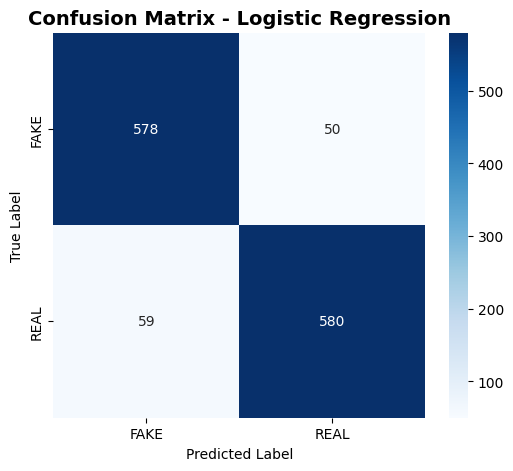

In [11]:
# ============================================
# CONFUSION MATRIX - BASELINE MODEL
# ============================================

cm_baseline = confusion_matrix(y_test, y_pred_baseline)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues',
            xticklabels=['FAKE', 'REAL'],
            yticklabels=['FAKE', 'REAL'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [12]:
# ============================================
# ADVANCED MODEL: LSTM (Long Short-Term Memory)
# ============================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


# Prepare sequences for LSTM

tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)


X_train_seq = tokenizer.texts_to_sequences(X_train) # Converts each training article from words to a list of integers
X_test_seq = tokenizer.texts_to_sequences(X_test) #Converts test articles to integer sequences using the SAME mapping from training.



# Pad sequences

max_length = 200
X_train_pad = pad_sequences(X_train_seq, 
                             maxlen=max_length,
                             padding='post', 
                             truncating='post')  

X_test_pad = pad_sequences(X_test_seq,
                            maxlen=max_length,
                            padding='post',
                            truncating='post')


In [13]:
# =============================================================
# GloVe Embeddings (Global Vectors) for Word Representation
# =============================================================


def load_glove_embeddings(file_path='glove.6B.100d.txt'):
    # Load GloVe embeddings into a dictionary
    embeddings_index = {} 


    with open(file_path, encoding='utf-8') as f: 
        for line in f: 
            values = line.split() 
            word = values[0] 
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs  
            
    print(f"Loaded {len(embeddings_index)} word vectors")
    return embeddings_index

# Load the embeddings
glove_embeddings = load_glove_embeddings('glove.6B.100d.txt') 

Loaded 400000 word vectors


In [14]:
# Use the same tokenizer you already have from your notebook
# ( tokenizer is already fit on your training data)

embedding_dim = 100  # Must match the GloVe file you downloaded
vocab_size = len(tokenizer.word_index) + 1  # +1 for padding (index 0)


# Initialize embedding matrix with zeros
embedding_matrix = np.zeros((vocab_size, embedding_dim))


# Fill the matrix with GloVe vectors where available
for word, i in tokenizer.word_index.items(): 
    embedding_vector = glove_embeddings.get(word) 
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector 


print(f"Embedding matrix shape: {embedding_matrix.shape}") 

Embedding matrix shape: (52267, 100)


In [15]:
# Build LSTM with pre-trained GloVe embeddings


lstm_model = Sequential([ # Creates a Sequential model - a linear stack of layers where data flows from first layer to last layer.
    
    # Embedding layer with pre-trained GloVe weights
    Embedding(
        input_dim=vocab_size, 
        output_dim=embedding_dim, 
        weights=[embedding_matrix],  # <- GLOVE WEIGHTS GO HERE 
        input_length=max_length, 
        trainable=True  #  Allow embeddings to be fine-tuned during training
    ),
    Bidirectional(LSTM(128, dropout=0.3, recurrent_dropout=0.3, return_sequences=False)),
    Dense(64, activation='relu'), # 64 ==> Number of neurons (intermediate representation size) , activation	'relu'	Activation function (max(0, x))
    Dropout(0.5), # Randomly turns off 50% of neurons during training
    Dense(1, activation='sigmoid') # 1 ==> Binary classification (FAKE or REAL) , activation ==> 'sigmoid' ==> Squashes output to probability between 0 and 1
])


lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [16]:
# ============================================
# CONVERT LABELS TO NUMERIC
# ============================================

# Check current label values
print(f"Original labels: {y_train.unique()}")

# Convert to numeric (FAKE -> 0, REAL -> 1)
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_numeric = label_encoder.fit_transform(y_train)
y_test_numeric = label_encoder.transform(y_test)

# Verify conversion
print(f"Numeric labels: {set(y_train_numeric)}")
print(f"Mapping: FAKE={label_encoder.transform(['FAKE'])[0]}, REAL={label_encoder.transform(['REAL'])[0]}")

Original labels: ['REAL' 'FAKE']
Numeric labels: {np.int64(0), np.int64(1)}
Mapping: FAKE=0, REAL=1


In [17]:
# Train LSTM with numeric labels

history = lstm_model.fit( 
    X_train_pad, y_train_numeric,
    epochs=5, 
    batch_size=32, 
    validation_split=0.2, 
    verbose=1
)



Epoch 1/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 53s 380ms/step - accuracy: 0.7316 - loss: 0.5372 - val_accuracy: 0.8274 - val_loss: 0.3864
Epoch 2/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 51s 401ms/step - accuracy: 0.8621 - loss: 0.3388 - val_accuracy: 0.8748 - val_loss: 0.3072
Epoch 3/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 52s 409ms/step - accuracy: 0.9068 - loss: 0.2341 - val_accuracy: 0.8866 - val_loss: 0.2681
Epoch 4/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 50s 393ms/step - accuracy: 0.9430 - loss: 0.1542 - val_accuracy: 0.8915 - val_loss: 0.2811
Epoch 5/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 52s 412ms/step - accuracy: 0.9642 - loss: 0.0963 - val_accuracy: 0.8974 - val_loss: 0.2840


In [18]:
# Evaluate
loss, accuracy = lstm_model.evaluate(X_test_pad, y_test_numeric)
print(f"LSTM Accuracy: {accuracy * 100:.1f}%")

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.9155 - loss: 0.2547
LSTM Accuracy: 91.6%


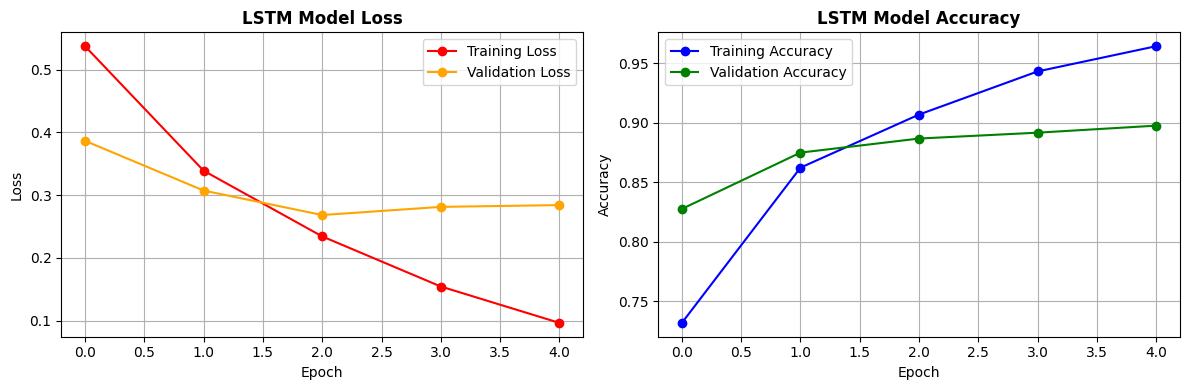

In [19]:
# ============================================
# LSTM TRAINING HISTORY PLOT
# ============================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
ax1.plot(history.history['loss'], label='Training Loss', marker='o', color='red')
ax1.plot(history.history['val_loss'], label='Validation Loss', marker='o', color='orange')
ax1.set_title('LSTM Model Loss', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(history.history['accuracy'], label='Training Accuracy', marker='o', color='blue')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o', color='green')
ax2.set_title('LSTM Model Accuracy', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [20]:
# ============================================
# LSTM EVALUATION & CONFUSION MATRIX
# ============================================

# Get predictions
y_pred_lstm_numeric = (lstm_model.predict(X_test_pad) > 0.5).astype(int).flatten()

# Calculate metrics using the predictions
accuracy_lstm = accuracy_score(y_test_numeric, y_pred_lstm_numeric)
precision_lstm = precision_score(y_test_numeric, y_pred_lstm_numeric)
recall_lstm = recall_score(y_test_numeric, y_pred_lstm_numeric)
f1_lstm = f1_score(y_test_numeric, y_pred_lstm_numeric)




40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step


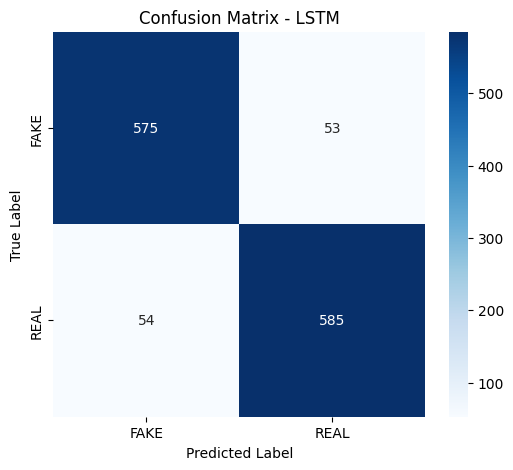

In [21]:
# Confusion matrix

cm_lstm = confusion_matrix(y_test_numeric, y_pred_lstm_numeric)
# print("\nLSTM Confusion Matrix:")
# print(cm_lstm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - LSTM')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


In [22]:
# ============================================
# CALCULATE LSTM METRICS 
# ============================================

# Get LSTM predictions (numeric)
y_pred_lstm_numeric = (lstm_model.predict(X_test_pad) > 0.5).astype(int)

# Calculate metrics for LSTM

accuracy_lstm = accuracy_score(y_test_numeric, y_pred_lstm_numeric)
precision_lstm = precision_score(y_test_numeric, y_pred_lstm_numeric)
recall_lstm = recall_score(y_test_numeric, y_pred_lstm_numeric)
f1_lstm = f1_score(y_test_numeric, y_pred_lstm_numeric)

print("LSTM Metrics:")
print(f"Accuracy: {accuracy_lstm:.4f}")
print(f"Precision: {precision_lstm:.4f}")
print(f"Recall: {recall_lstm:.4f}")
print(f"F1-Score: {f1_lstm:.4f}")

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step
LSTM Metrics:
Accuracy: 0.9155
Precision: 0.9169
Recall: 0.9155
F1-Score: 0.9162


In [23]:
# ============================================
# SIMPLE TEST: ORIGINAL MODEL
# ============================================

def test_original_model(text): 
    clean = preprocess_text(text)
    vec = tfidf_vectorizer.transform([clean]) 

    proba = baseline_model.predict_proba(vec)[0][1] # Gets the probability that this article is REAL news.
    prediction = "REAL" if proba > 0.5 else "FAKE" # Converts probability to a class label using 0.5 threshold.
    return prediction, proba

# Test a few examples
test_texts = [
    ("President Biden signs Inflation Reduction Act into law at White House ceremony", "REAL"),
    ("You won't believe this shocking discovery", "FAKE"),
    ("Breaking news!!!!", "FAKE"),
]

for text, expected in test_texts:
    pred, prob = test_original_model(text)
    print(f"Text: {text}")
    print(f"Expected: {expected} | Predicted: {pred} | REAL prob: {prob:.3f}")
    print("-" * 50)

Text: President Biden signs Inflation Reduction Act into law at White House ceremony
Expected: REAL | Predicted: REAL | REAL prob: 0.539
--------------------------------------------------
Text: You won't believe this shocking discovery
Expected: FAKE | Predicted: FAKE | REAL prob: 0.195
--------------------------------------------------
Text: Breaking news!!!!
Expected: FAKE | Predicted: FAKE | REAL prob: 0.133
--------------------------------------------------


In [24]:
# ============================================
# MODEL COMPARISON 
# ============================================


print("MODEL COMPARISON:")


# For baseline model (Logistic Regression)
y_pred_baseline_strings = baseline_model.predict(X_test_tfidf)

# Convert string predictions to numeric using the same label encoder
y_pred_baseline_numeric = label_encoder.transform(y_pred_baseline_strings)

# Calculate metrics
accuracy_baseline = accuracy_score(y_test_numeric, y_pred_baseline_numeric)
precision_baseline = precision_score(y_test_numeric, y_pred_baseline_numeric)
recall_baseline = recall_score(y_test_numeric, y_pred_baseline_numeric)
f1_baseline = f1_score(y_test_numeric, y_pred_baseline_numeric)

# For LSTM 
y_pred_lstm_numeric = (lstm_model.predict(X_test_pad, verbose=0) > 0.5).astype(int).flatten()

accuracy_lstm = accuracy_score(y_test_numeric, y_pred_lstm_numeric)
precision_lstm = precision_score(y_test_numeric, y_pred_lstm_numeric)
recall_lstm = recall_score(y_test_numeric, y_pred_lstm_numeric)
f1_lstm = f1_score(y_test_numeric, y_pred_lstm_numeric)


# Create comparison table
comparison_data = {
    'Model': ['Logistic Regression (TF-IDF)', 'LSTM (GloVe)'],
    'Accuracy': [accuracy_baseline, accuracy_lstm],
    'Precision': [precision_baseline, precision_lstm],
    'Recall': [recall_baseline, recall_lstm],
    'F1-Score': [f1_baseline, f1_lstm]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))



MODEL COMPARISON:
                       Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression (TF-IDF)  0.913970   0.920635 0.907668  0.914106
                LSTM (GloVe)  0.915549   0.916928 0.915493  0.916210


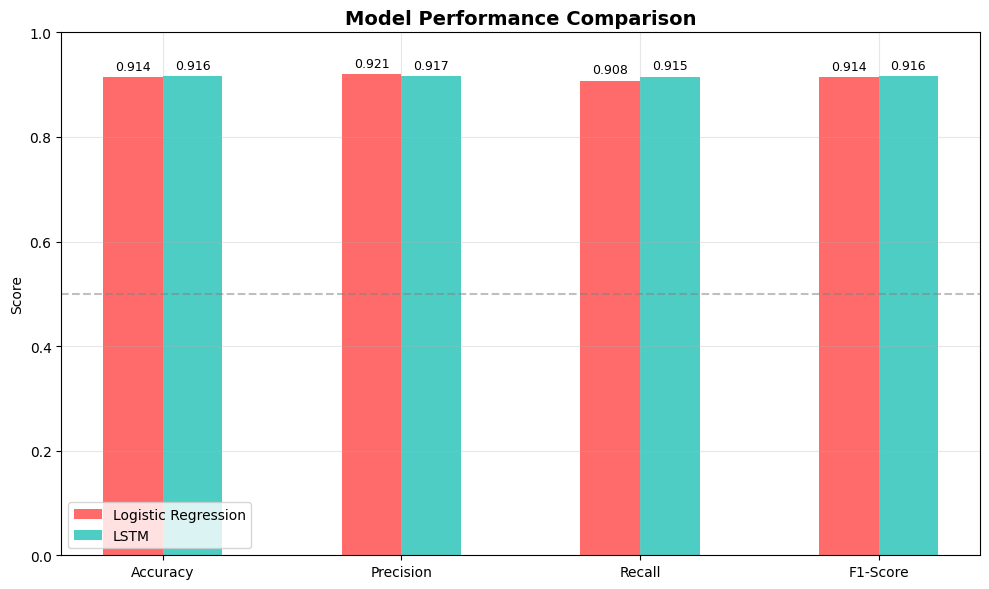

In [25]:
# ============================================
# MODEL COMPARISON BAR CHART
# ============================================

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_scores = [accuracy_baseline, precision_baseline, recall_baseline, f1_baseline]
lstm_scores = [accuracy_lstm, precision_lstm, recall_lstm, f1_lstm]

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, baseline_scores, width, label='Logistic Regression', color='#ff6b6b')
rects2 = ax.bar(x + width/2, lstm_scores, width, label='LSTM', color='#4ecdc4')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

# Add value labels on bars
for rect in rects1:
    height = rect.get_height()
    ax.annotate(f'{height:.3f}', xy=(rect.get_x() + rect.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

for rect in rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.3f}', xy=(rect.get_x() + rect.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step


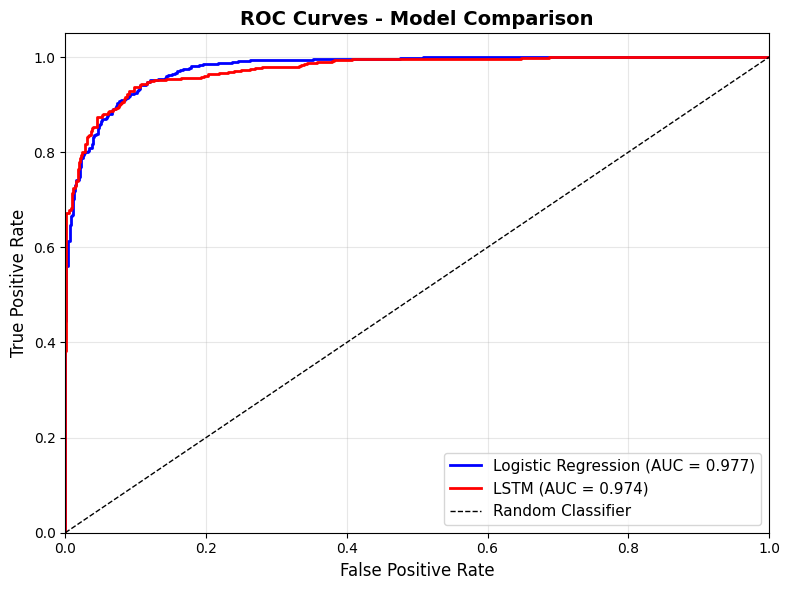


AUC Summary:
   Logistic Regression AUC: 0.9769
   LSTM AUC: 0.9738
   Difference: 0.0031


In [26]:
# ============================================
# ROC CURVES - Model Comparison
# ============================================

from sklearn.metrics import roc_curve, auc

# Get prediction probabilities
# For Logistic Regression (already trained)
y_pred_proba_lr = baseline_model.predict_proba(X_test_tfidf)[:, 1]

# For LSTM (already trained)
y_pred_proba_lstm = lstm_model.predict(X_test_pad).flatten()

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test_numeric, y_pred_proba_lr)
fpr_lstm, tpr_lstm, _ = roc_curve(y_test_numeric, y_pred_proba_lstm)

# Calculate AUC scores
auc_lr = auc(fpr_lr, tpr_lr)
auc_lstm = auc(fpr_lstm, tpr_lstm)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, 'b-', linewidth=2, 
         label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot(fpr_lstm, tpr_lstm, 'r-', linewidth=2, 
         label=f'LSTM (AUC = {auc_lstm:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAUC Summary:")
print(f"   Logistic Regression AUC: {auc_lr:.4f}")
print(f"   LSTM AUC: {auc_lstm:.4f}")
print(f"   Difference: {abs(auc_lr - auc_lstm):.4f}")

In [27]:
# ============================================
# PATTERN EXTRACTION 
# ============================================


# 1. Simple statistics

print("DATASET STATISTICS")
print(f"Total articles: {len(df)}")
print(f"FAKE news: {(df['label'] == 'FAKE').sum()} ({(df['label'] == 'FAKE').mean()*100:.1f}%)")
print(f"REAL news: {(df['label'] == 'REAL').sum()} ({(df['label'] == 'REAL').mean()*100:.1f}%)")

# 2. Common patterns in FAKE news
fake_words = []
for tokens in df[df['label'] == 'FAKE']['tokens']:
    fake_words.extend(tokens)

fake_patterns = Counter(fake_words).most_common(10)
print("\n COMMON PATTERNS IN FAKE NEWS:")
for word, count in fake_patterns:
    print(f"   • '{word}': {count} times")

# 3. Common patterns in REAL news
real_words = []
for tokens in df[df['label'] == 'REAL']['tokens']:
    real_words.extend(tokens)

real_patterns = Counter(real_words).most_common(10)
print("\n COMMON PATTERNS IN REAL NEWS:")
for word, count in real_patterns:
    print(f"   • '{word}': {count} times")




DATASET STATISTICS
Total articles: 6335
FAKE news: 3164 (49.9%)
REAL news: 3171 (50.1%)

 COMMON PATTERNS IN FAKE NEWS:
   • 'clinton': 7077 times
   • 'us': 6879 times
   • 'trump': 6621 times
   • 'peopl': 5526 times
   • 'state': 5447 times
   • 'one': 5230 times
   • 'would': 4887 times
   • 'hillari': 4557 times
   • 'like': 4117 times
   • 'elect': 4071 times

 COMMON PATTERNS IN REAL NEWS:
   • 'said': 17187 times
   • 'trump': 15470 times
   • 'clinton': 10790 times
   • 'state': 10025 times
   • 'republican': 8064 times
   • 'would': 7780 times
   • 'presid': 6842 times
   • 'say': 6640 times
   • 'one': 6634 times
   • 'peopl': 6303 times


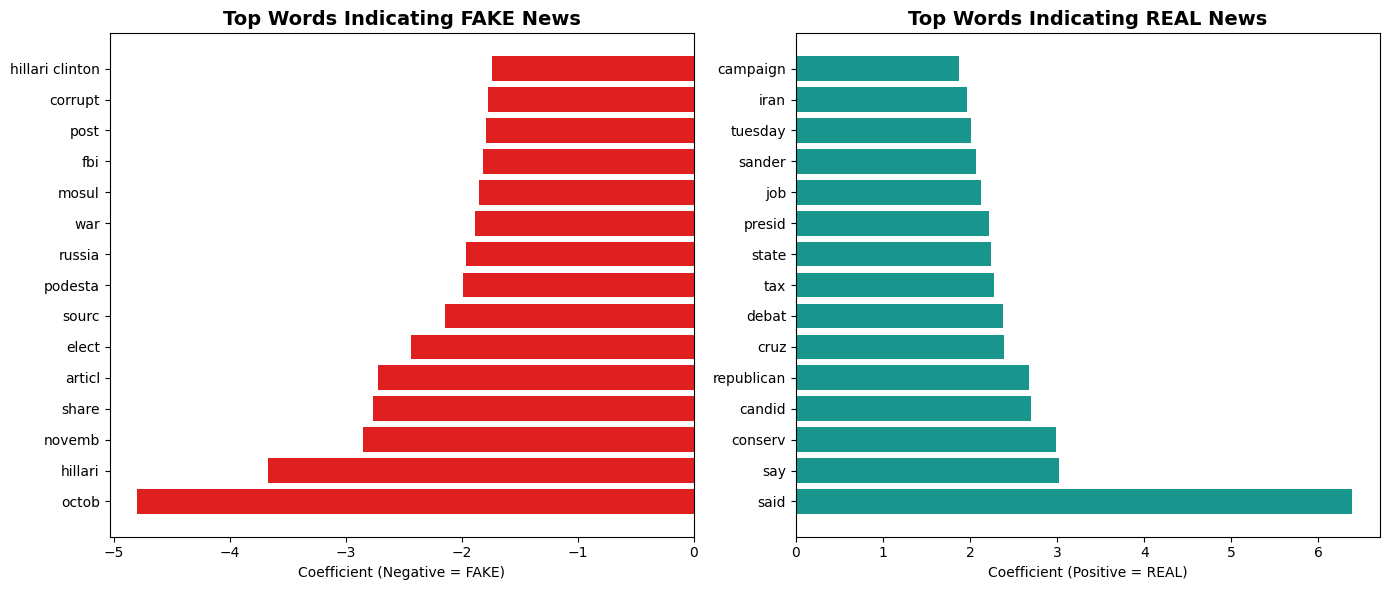

In [28]:
# ============================================
# FEATURE IMPORTANCE - TOP WORDS PLOT
# ============================================


# Get feature names and coefficients
feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients = baseline_model.coef_[0]

# Get top 15 positive (REAL) and negative (FAKE) coefficients
top_real_idx = np.argsort(coefficients)[-15:][::-1]
top_fake_idx = np.argsort(coefficients)[:15]

top_real_words = [feature_names[i] for i in top_real_idx]
top_real_coef = [coefficients[i] for i in top_real_idx]
top_fake_words = [feature_names[i] for i in top_fake_idx]
top_fake_coef = [coefficients[i] for i in top_fake_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# FAKE news indicators (negative coefficients)
ax1.barh(top_fake_words, top_fake_coef, color="#e02020")
ax1.set_title('Top Words Indicating FAKE News', fontsize=14, fontweight='bold')
ax1.set_xlabel('Coefficient (Negative = FAKE)')
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# REAL news indicators (positive coefficients)
ax2.barh(top_real_words, top_real_coef, color="#18958d")
ax2.set_title('Top Words Indicating REAL News', fontsize=14, fontweight='bold')
ax2.set_xlabel('Coefficient (Positive = REAL)')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

WORD CLOUD - Most Common Words


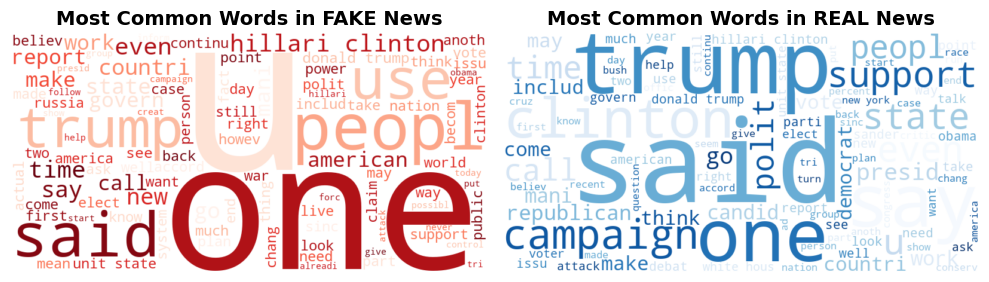

In [29]:

# ============================================
# WORD CLOUD - Most Common Words
# ============================================

from wordcloud import WordCloud



print("WORD CLOUD - Most Common Words")


# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Word cloud for FAKE news
fake_text = ' '.join(df[df['label'] == 'FAKE']['clean_text'].astype(str))
wordcloud_fake = WordCloud(width=800, height=400, 
                           background_color='white',
                           colormap='Reds',
                           max_words=100).generate(fake_text)

axes[0].imshow(wordcloud_fake, interpolation='bilinear')
axes[0].set_title('Most Common Words in FAKE News', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Word cloud for REAL news
real_text = ' '.join(df[df['label'] == 'REAL']['clean_text'].astype(str))
wordcloud_real = WordCloud(width=800, height=400, 
                           background_color='white',
                           colormap='Blues',
                           max_words=100).generate(real_text)

axes[1].imshow(wordcloud_real, interpolation='bilinear')
axes[1].set_title('Most Common Words in REAL News', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()